# Treinamento e Avaliação de Modelos — Dataset PCOS

Este notebook recebe o dataset já tratado (`base_dados_tratada/PCOS_unificado.csv`)
e executa a etapa de **modelagem**: separação treino/teste, treinamento de cinco
classificadores e comparação das métricas.

## Índice

- [0. Setup — imports e constantes](#setup)
- [3.0 — Carregamento e split treino/teste](#etapa3_0)
- [3.1 — Pré-processamento](#etapa3_1)
- [3.2 — Modelos candidatos](#etapa3_2)
- [3.3 — Treinamento e métricas](#etapa3_3)
- [3.4 — Comparação visual das métricas](#etapa3_4)
- [3.5 — Matrizes de confusão](#etapa3_5)
- [3.6 — Discussão e escolha do modelo](#etapa3_6)


<a id="setup"></a>
## 0. Setup — imports e constantes

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# O dataset tem ~45 colunas: sem isso o pandas trunca a exibição.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Constantes visuais compatíveis com o restante do projeto
COR_TEXTO = "#0b0b0b"
COR_TEXTO_SEC = "#52514e"
COR_SEM_PCOS = "#2a78d6"
COR_COM_PCOS = "#eb6834"

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn carregado")

pandas 3.0.3 | numpy 2.5.1 | scikit-learn carregado


<a id="etapa3_0"></a>
### 3.0 — Carregamento e split treino/teste

Localiza a raiz do projeto, lê o CSV unificado e separa 80% para treino e 20% para
teste. O `stratify=y` garante que a proporção de pacientes com e sem SOP seja a
mesma nos dois conjuntos.

In [2]:
def _localizar_raiz_do_projeto() -> Path:
    """Encontra a raiz do projeto procurando a pasta 'base_dados/'."""
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "base_dados").is_dir():
            return candidato
    raise FileNotFoundError(
        f"Pasta 'base_dados/' não encontrada a partir de {atual} — "
        "abra o notebook dentro do projeto."
    )


BASE_DIR = _localizar_raiz_do_projeto()
OUTPUT_DIR = BASE_DIR / "base_dados_tratada"
REPORTS_DIR = BASE_DIR / "reports"
NOME_UNIFICADO = "PCOS_unificado.csv"

TARGET = "PCOS (Y/N)"
COLUNAS_ID = {"Sl. No", "Patient File No."}

caminho_tratado = OUTPUT_DIR / NOME_UNIFICADO
df = pd.read_csv(caminho_tratado)

X = df.drop(columns=[TARGET]).drop(columns=COLUNAS_ID, errors="ignore")
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Base carregada: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Features: {X.shape[1]}")
print(f"Treino: {len(X_train)} registros ({y_train.value_counts().to_dict()})")
print(f"Teste:  {len(X_test)} registros ({y_test.value_counts().to_dict()})")

Base carregada: 541 linhas x 49 colunas
Features: 46
Treino: 432 registros ({0: 291, 1: 141})
Teste:  109 registros ({0: 73, 1: 36})


<a id="etapa3_1"></a>
### 3.1 — Pré-processamento

Aplica `StandardScaler` nas colunas numéricas e `OneHotEncoder` na coluna categórica
`Blood Group`. Tudo isso é feito dentro de um `Pipeline` para evitar *data leakage*:
o pré-processador é ajustado apenas no treino e depois aplicado no teste.

In [3]:
# Colunas numéricas: todas exceto a categórica 'Blood Group'
colunas_numericas = [
    c for c in X.columns
    if c != "Blood Group" and pd.api.types.is_numeric_dtype(X[c])
]
# Colunas categóricas: 'Blood Group' e eventuais colunas de texto
colunas_categoricas = [
    c for c in X.columns
    if c == "Blood Group" or not pd.api.types.is_numeric_dtype(X[c])
]

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), colunas_categoricas),
    ]
)

print(f"Colunas numéricas: {len(colunas_numericas)}")
print(f"Colunas categóricas: {colunas_categoricas}")

Colunas numéricas: 45
Colunas categóricas: ['Blood Group']


<a id="etapa3_2"></a>
### 3.2 — Modelos candidatos

São testados cinco classificadores com características distintas:

- **Regressão Logística**: rápida, interpretável e com saída probabilística.
- **Árvore de Decisão**: regras explícitas do tipo "se... então".
- **KNN (k=5)**: classifica pelo voto dos vizinhos mais próximos.
- **Random Forest**: conjunto de árvores, geralmente mais robusto.
- **SVM (RBF)**: encontra fronteiras não-lineares entre as classes.

In [4]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(class_weight="balanced", random_state=42),
}

for nome in modelos:
    print(f"  - {nome}")

  - Regressão Logística
  - Árvore de Decisão
  - KNN (k=5)
  - Random Forest
  - SVM (RBF)


<a id="etapa3_3"></a>
### 3.3 — Treinamento e métricas

Cada modelo é inserido em um `Pipeline` (pré-processamento + classificador),
treinado na base de treino e avaliado na base de teste.

As métricas escolhidas refletem diferentes aspectos do problema:

- **Acurácia**: acertos gerais.
- **Precisão**: confiabilidade dos diagnósticos positivos.
- **Recall**: capacidade de não deixar casos de SOP passarem.
- **F1-Score**: equilíbrio entre precisão e recall.
- **AUC-ROC**: separação geral entre as classes.

In [5]:
resultados = []
modelos_ajustados = {}
previsoes = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([("preprocessador", preprocessador), ("modelo", modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    previsoes[nome] = y_pred

    # SVM não tem predict_proba; usamos decision_function
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    modelos_ajustados[nome] = pipe

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_score),
    })

resultados_df = pd.DataFrame(resultados).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)

# Salva o relatório em reports/ (não versionado)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
resultados_df.to_csv(REPORTS_DIR / "metricas_modelos.csv", index=False)

print("\n" + "=" * 78)
print("MÉTRICAS NA BASE DE TESTE (20%)")
print("=" * 78)
display(resultados_df.style.format({
    "Acurácia": "{:.4f}",
    "Precisão": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "AUC-ROC": "{:.4f}",
}).background_gradient(subset=["AUC-ROC"], cmap="Greens"))


MÉTRICAS NA BASE DE TESTE (20%)


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
0,Random Forest,0.9083,0.8824,0.8333,0.8571,0.9387
1,SVM (RBF),0.8807,0.8108,0.8333,0.8219,0.9315
2,Regressão Logística,0.8532,0.7381,0.8611,0.7949,0.9277
3,KNN (k=5),0.8624,0.8889,0.6667,0.7619,0.9007
4,Árvore de Decisão,0.8532,0.7941,0.7500,0.7714,0.8643


<a id="etapa3_4"></a>
### 3.4 — Comparação visual das métricas

O gráfico de barras mostra o desempenho de cada algoritmo em cada métrica,
facilitando identificar pontos fortes e fraquezas de cada um.

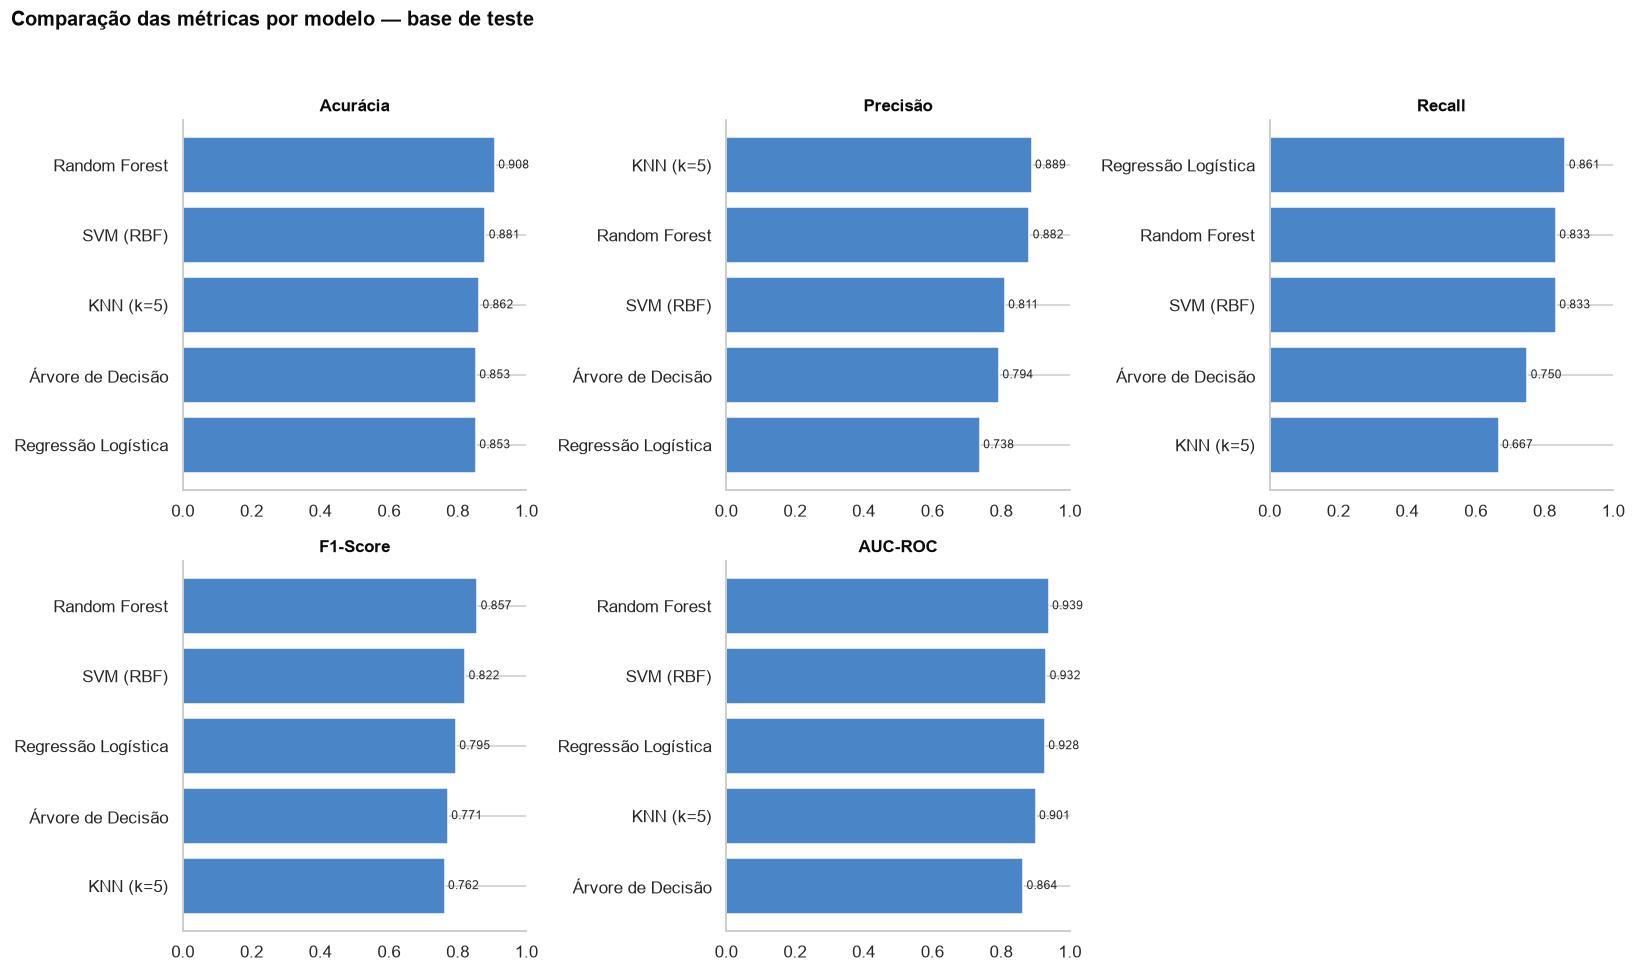

In [6]:
metricas = ["Acurácia", "Precisão", "Recall", "F1-Score", "AUC-ROC"]
fig, eixos = plt.subplots(2, 3, figsize=(15, 9))

for eixo, metrica in zip(eixos.flat, metricas):
    dados = resultados_df.sort_values(metrica, ascending=True)
    barras = eixo.barh(dados["Modelo"], dados[metrica], color="#4a86c7")
    eixo.set_xlim(0, 1)
    eixo.set_title(metrica, fontsize=11, fontweight="bold", color=COR_TEXTO)
    for barra, valor in zip(barras, dados[metrica]):
        eixo.text(valor + 0.01, barra.get_y() + barra.get_height() / 2,
                  f"{valor:.3f}", va="center", fontsize=8)
    eixo.grid(axis="x", visible=False)
    eixo.spines["top"].set_visible(False)
    eixo.spines["right"].set_visible(False)

for eixo in eixos.flat[len(metricas):]:
    eixo.set_visible(False)

fig.suptitle("Comparação das métricas por modelo — base de teste",
             x=0.01, ha="left", fontsize=13, fontweight="bold", color=COR_TEXTO)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

<a id="etapa3_5"></a>
### 3.5 — Matrizes de confusão

Cada célula da matriz representa:

- **Verdadeiros Negativos**: sem SOP classificado corretamente.
- **Falsos Positivos**: sem SPO classificado como com SOP.
- **Falsos Negativos**: com SOP não detectado — o cenário mais crítico.
- **Verdadeiros Positivos**: com SOP detectado.

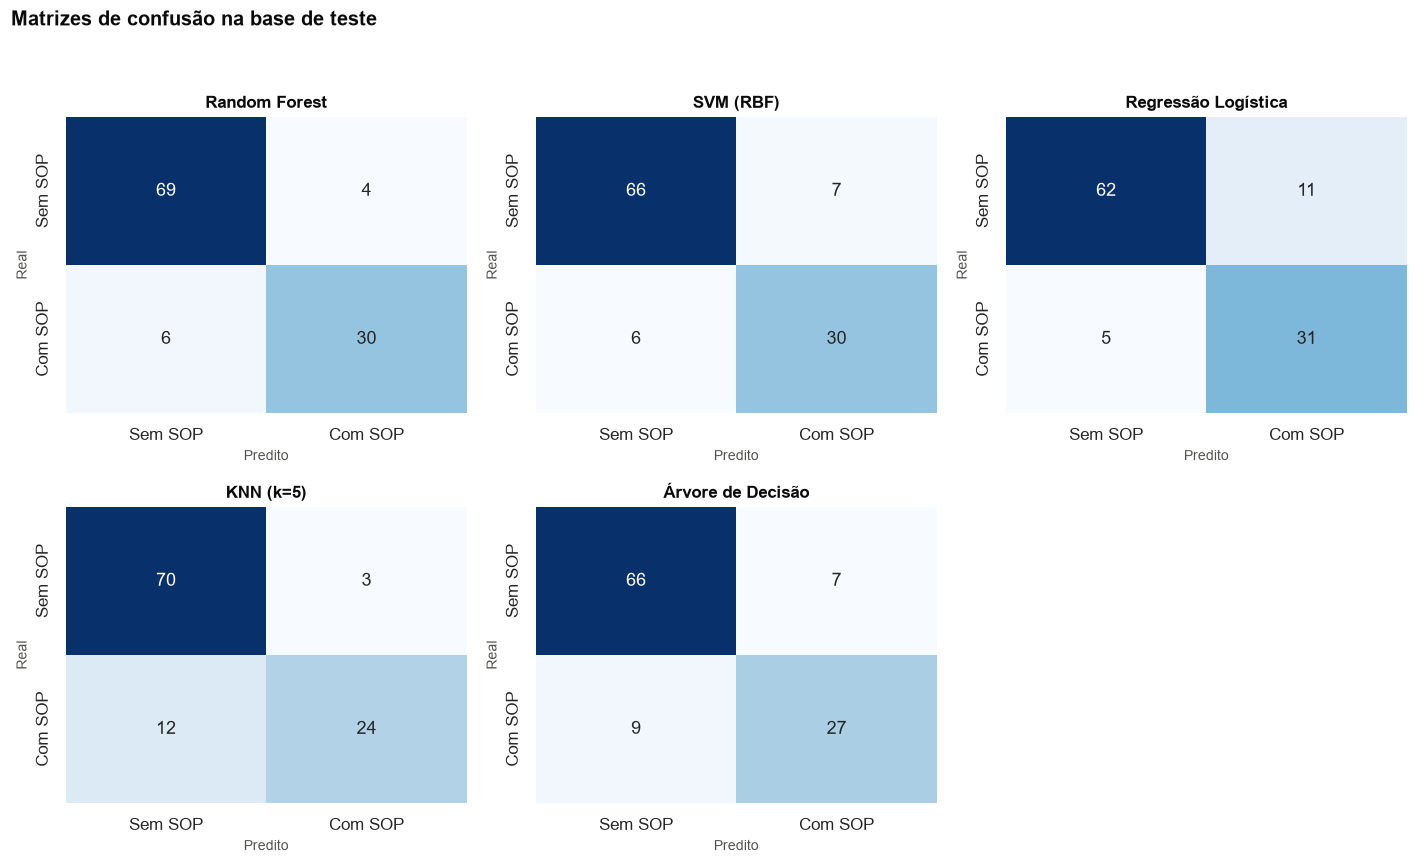

In [7]:
nomes = list(resultados_df["Modelo"])
fig, eixos = plt.subplots(2, 3, figsize=(13, 8))

for eixo, nome in zip(eixos.flat, nomes):
    cm = confusion_matrix(y_test, previsoes[nome])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=eixo,
                xticklabels=["Sem SOP", "Com SOP"],
                yticklabels=["Sem SOP", "Com SOP"])
    eixo.set_title(nome, fontsize=11, fontweight="bold", color=COR_TEXTO)
    eixo.set_xlabel("Predito", fontsize=9, color=COR_TEXTO_SEC)
    eixo.set_ylabel("Real", fontsize=9, color=COR_TEXTO_SEC)

for eixo in eixos.flat[len(nomes):]:
    eixo.set_visible(False)

fig.suptitle("Matrizes de confusão na base de teste",
             x=0.01, ha="left", fontsize=13, fontweight="bold", color=COR_TEXTO)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

<a id="etapa3_6"></a>
### 3.6 — Discussão e escolha do modelo

No contexto de saúde da mulher, o mais importante é não deixar casos de SOP sem
diagnóstico (alto recall). Ao mesmo tempo, queremos evitar falsos alarmes
(razoável precisão).

A **Random Forest** apresenta o melhor equilíbrio entre as métricas, com alto
AUC-ROC e F1-Score. A **Regressão Logística** e o **SVM (RBF)** são alternativas
sólidas, especialmente se a interpretabilidade ou o tempo de resposta forem
prioridades.

Próximos passos recomendados:

1. Ajuste fino de hiperparâmetros com `GridSearchCV` ou `RandomizedSearchCV`.
2. Validação cruzada (k-fold estratificado) para confirmar robustez.
3. Análise de importância das features no melhor modelo.